## Sex and age across cancer types

Sex and age of the atlas cell lines, from `../pccma_cell_line_metadata.csv`, with cancer groups grouped by tissue site, in the
order they appear down the body figure
(sites and groups from `plotting_helpers/cancer_type_categories.yaml`, site colours from the repo-level `themes.R`) and a small white space
between sites. Every panel has a light grid, dotted guide lines along each row, and a frame round each tissue site block.

* **Left, sex:** cell lines per cancer group, stacked by sex (female, male, unknown), with the group total at the end of each bar.
* **Right, age:** each dot is a cell line at its age in years, on the same rows as the sex bars. The black tick is the group
  median and is labelled with its value. Cell lines with no age are not drawn.
* **Top right, age histogram:** the age distribution of all cell lines with a known age, in one colour, with the total
  number of unknown ages noted (it is not split by cancer type).

`U2-OS` has one row per plate condition; each cell line is counted once.

In [1]:
suppressPackageStartupMessages({
  library(patchwork)
  library(stringr)
})

source(file.path("..", "plotting_helpers", "cell_line_figure_utils.R"))

metadata_file <- file.path("..", "pccma_cell_line_metadata.csv")
categories_file <- file.path("..", "plotting_helpers", "cancer_type_categories.yaml")
output_dir <- "figures"
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

### Prepare the data

In [2]:
atlas <- prepare_cancer_type_data(metadata_file, categories_file)
# sites in the order they appear down the body figure (top to bottom of the anatogram), groups by size within each site
present <- as.character(atlas$site_counts$site)
site_order <- site_info$site[order(-site_info$anchor_y)]
site_order <- site_order[site_order %in% present]
group_order <- atlas$group_counts %>%
  mutate(site = as.character(site)) %>%
  arrange(match(site, site_order), desc(n), cancer_group)

cl <- atlas$cell_lines %>%
  transmute(cell_line_key, cell_line,
            site = factor(site, site_order),
            cancer_group = factor(cancer_group, rev(as.character(group_order$cancer_group))),
            sex = factor(coalesce(sex, "Unknown"), sex_levels),
            age = as.numeric(age))
stopifnot(!anyNA(cl$cancer_group))

sex_counts <- cl %>% count(site, cancer_group, sex)
group_totals <- cl %>% count(site, cancer_group)
site_totals <- cl %>% count(site)
n_total <- nrow(cl)
n_unknown_age <- sum(is.na(cl$age))
cat(sprintf("cell lines: %d | unknown sex: %d | unknown age: %d\n", n_total, sum(cl$sex == "Unknown"), n_unknown_age))

cell lines: 56 | unknown sex: 15 | unknown age: 19


### Shared look

Large text, a light grid on both axes, dotted guide lines along each row and a thin frame round each tissue-site block.
Long labels are wrapped onto several lines.

In [3]:
base_size <- 15
grid_theme <- theme(
  panel.grid.major.x = element_line(colour = "grey82", linewidth = 0.45),
  panel.grid.minor.x = element_line(colour = "grey92", linewidth = 0.3),
  panel.grid.major.y = element_line(colour = "grey70", linewidth = 0.35, linetype = "dotted"),
  panel.background = element_rect(fill = NA, colour = "grey75", linewidth = 0.4),
  panel.spacing.y = unit(0.8, "lines"),
  axis.title.y = element_blank(),
  axis.text.y = element_text(size = base_size - 1.5, colour = "black", lineheight = 0.9),
  axis.text.x = element_text(size = base_size - 2, colour = "grey20"),
  axis.title.x = element_text(size = base_size, colour = "grey10", margin = margin(t = 6))
)
site_labels <- setNames(str_wrap(paste0(str_remove(site_totals$site, " lines$"), " (n=", site_totals$n, ")"), 16),   # "Normal reference lines" -> "Normal reference"
                        as.character(site_totals$site))
group_rows <- group_totals %>% select(site, cancer_group)
max_n <- max(group_totals$n)
age_max <- 24

### Sex, by cancer group

A band in the site colour at the left of each row, and a small white space between sites.

In [4]:
cns_site <- factor("Central nervous system", site_order)
cns_key_frame <- tibble(site = cns_site)
cns_key <- tibble(site = cns_site, sex = factor(sex_levels, sex_levels), y = c(3.65, 3.0, 2.35))

panel_sex <- ggplot(sex_counts, aes(n, cancer_group, fill = sex)) +
  geom_blank(data = group_rows, aes(y = cancer_group), inherit.aes = FALSE) +
  geom_col(width = 0.68, position = position_stack(reverse = TRUE))
for (s in site_order) {   # a band in the site colour at the left of each row
  panel_sex <- panel_sex +
    geom_tile(data = group_rows %>% filter(site == s), aes(x = -0.85, y = cancer_group), width = 0.6, height = 0.68,
              fill = site_colors[[s]], inherit.aes = FALSE)
}
panel_sex <- panel_sex +
  geom_text(data = group_totals, aes(n, cancer_group, label = n), hjust = -0.4, fontface = "bold", size = 5,
            inherit.aes = FALSE) +
  # sex legend, drawn by hand in the empty right side of the central nervous system block
  geom_rect(data = cns_key_frame, aes(xmin = 7.5, xmax = 13.2, ymin = 1.8, ymax = 4.7), fill = "white", colour = "grey75",
            linewidth = 0.3, inherit.aes = FALSE) +
  geom_text(data = cns_key_frame, aes(x = 7.95, y = 4.3, label = "Sex"), hjust = 0, fontface = "bold", size = 5.2,
            inherit.aes = FALSE) +
  geom_tile(data = cns_key, aes(x = 8.4, y = y, fill = sex), width = 0.6, height = 0.5, inherit.aes = FALSE) +
  geom_text(data = cns_key, aes(x = 9.0, y = y, label = sex), hjust = 0, size = 4.8, inherit.aes = FALSE) +
  facet_grid(site ~ ., scales = "free_y", space = "free_y", switch = "y", labeller = labeller(site = site_labels)) +
  scale_fill_manual(values = sex_colors, breaks = sex_levels) +
  scale_y_discrete(labels = function(x) ifelse(x == "Ewing sarcoma family", "Ewing sarcoma\nfamily", str_wrap(x, 22)),
                   expand = expansion(add = c(0.6, 0.85))) +
  scale_x_continuous(breaks = seq(0, max_n, by = 4), minor_breaks = seq(0, max_n + 2, by = 2),
                     limits = c(NA, 13.6), expand = expansion(mult = c(0, 0))) +
  labs(x = "Number of cell lines", fill = "Sex") +
  theme_panel(base_size) +
  grid_theme +
  theme(strip.placement = "outside",
        strip.text.y.left = element_text(angle = 0, hjust = 1, face = "bold", size = base_size - 2, lineheight = 0.95),
        legend.position = "none", plot.margin = margin(10, 2, 8, 10))

### Age, by cancer group and overall

The dots use the same rows as the sex bars. The histogram above them shares the age axis and shows all cell lines together.

In [5]:
age_cl <- cl %>% filter(!is.na(age))
age_scale <- scale_x_continuous(limits = c(0, age_max), breaks = seq(0, age_max, by = 4), minor_breaks = seq(0, age_max, by = 2),
                                expand = expansion(mult = c(0.01, 0)))

# median age of each group, written next to its black tick (left- or right-aligned near the panel edges)
first_group <- group_order$cancer_group[1]   # only the first row spells out "median age ="
medians <- age_cl %>%
  group_by(site, cancer_group) %>%
  summarise(med = median(age), .groups = "drop") %>%
  mutate(label = ifelse(cancer_group == first_group, sprintf("median age = %g y", round(med, 1)), sprintf("%g y", round(med, 1))),
         hjust = ifelse(med < 6, 0, ifelse(med > 18, 1, 0.5)))

panel_age <- ggplot(age_cl, aes(age, cancer_group)) +
  geom_blank(data = group_rows, aes(y = cancer_group), inherit.aes = FALSE) +
  geom_point(aes(colour = site), size = 3.6, alpha = 0.9, position = position_jitter(width = 0, height = 0.2, seed = 1)) +
  stat_summary(fun = median, geom = "point", shape = 124, size = 8, colour = "black") +
  geom_text(data = medians, aes(med, cancer_group, label = label, hjust = hjust), nudge_y = 0.3, vjust = 0, size = 4.4,
            fontface = "bold", colour = "grey10", inherit.aes = FALSE) +
  facet_grid(site ~ ., scales = "free_y", space = "free_y", switch = "y") +   # same strip side as the sex panel keeps the x axes aligned
  scale_colour_manual(values = site_colors, guide = "none") +
  scale_y_discrete(expand = expansion(add = c(0.6, 0.85))) +
  age_scale +
  labs(x = "Age (years)") +
  theme_panel(base_size) +
  grid_theme +
  theme(axis.text.y = element_blank(), strip.text = element_blank(), strip.placement = "outside",
        plot.margin = margin(10, 12, 8, 2))

# histogram of all cell lines with a known age: 1-year bins, one colour
bins <- age_cl %>% mutate(bin = floor(age)) %>% count(bin)
panel_hist <- ggplot(bins, aes(bin + 0.5, n)) +
  geom_col(width = 1, fill = "grey35", colour = "white", linewidth = 0.4) +
  annotate("text", x = age_max - 0.3, y = Inf, hjust = 1, vjust = 1.5, size = 5, fontface = "bold",
           label = sprintf("Unknown age: %d of %d", n_unknown_age, n_total)) +
  age_scale +
  scale_y_continuous(breaks = seq(0, 10, by = 2), minor_breaks = seq(0, 10, by = 1), expand = expansion(mult = c(0, 0.15))) +
  labs(x = "Age (years)", y = NULL) +
  theme_panel(base_size) +
  theme(panel.grid.major.x = element_line(colour = "grey82", linewidth = 0.45),
        panel.grid.minor.x = element_line(colour = "grey92", linewidth = 0.3),
        panel.grid.major.y = element_line(colour = "grey82", linewidth = 0.45),
        panel.grid.minor.y = element_line(colour = "grey92", linewidth = 0.3),
        panel.background = element_rect(fill = NA, colour = "grey75", linewidth = 0.4),
        plot.margin = margin(10, 12, 8, 0),
        axis.text.x = element_text(size = base_size - 2, colour = "grey20"),
        axis.title.x = element_text(size = base_size, colour = "grey10", margin = margin(t = 6)),
        axis.text.y = element_text(size = base_size - 2, colour = "grey20"),
        axis.title.y = element_blank())

### Combine and save

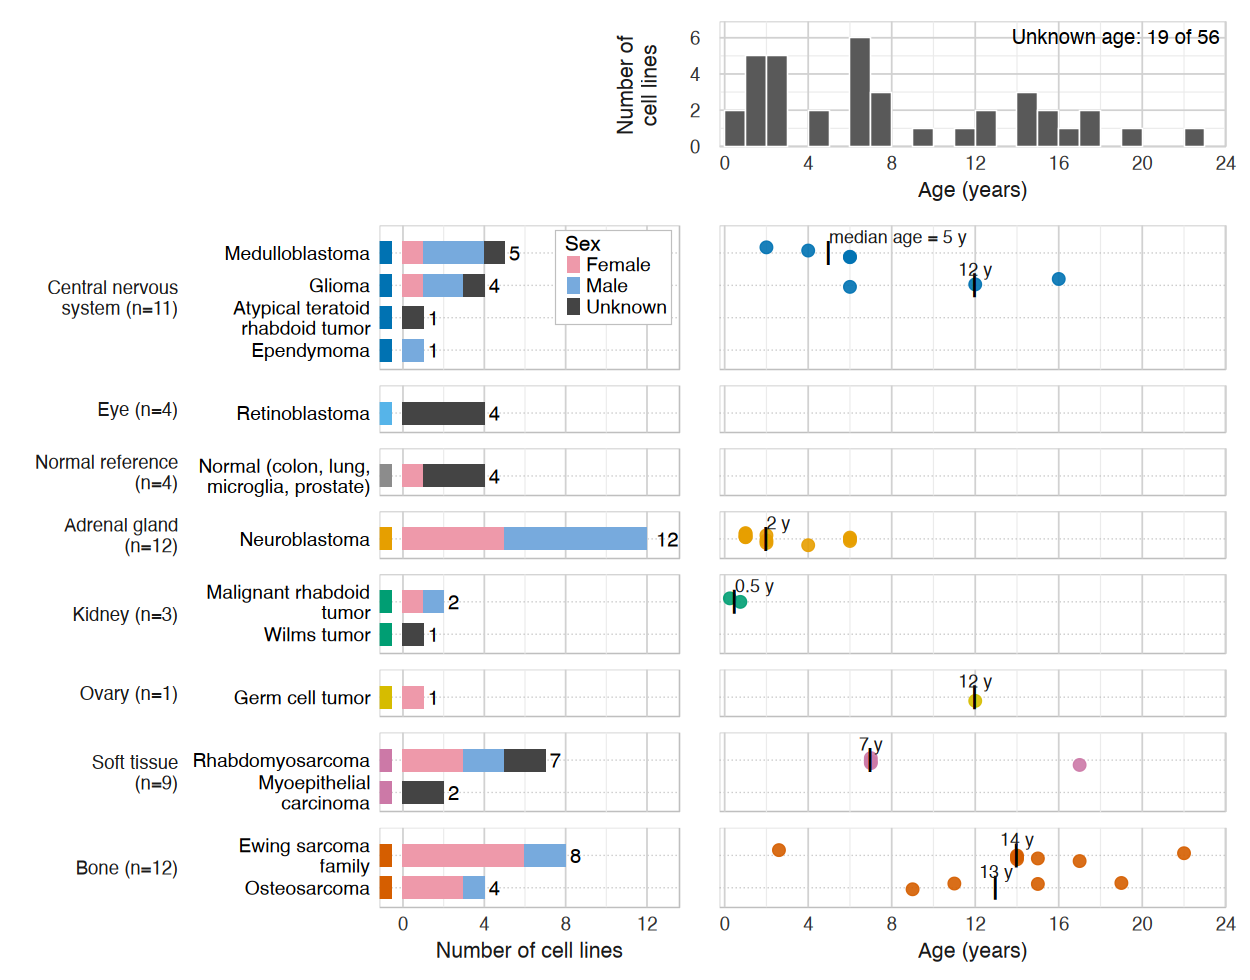

In [6]:
# The histogram's y title lives in the empty top-left cell, at its right edge next to the tick labels: as part of the
# histogram it would widen the histogram's left margin and push the age panel away from the sex panel.
panel_hist_ylab <- ggplot() +
  annotate("text", x = 0.955, y = 0.62, label = "Number of\ncell lines", angle = 90, hjust = 0.5, vjust = 0, size = base_size / .pt,
           colour = "grey10", lineheight = 0.95) +
  coord_cartesian(xlim = c(0, 1), ylim = c(0, 1), expand = FALSE) +
  theme_void()

fig_width <- 12.5; fig_height <- 9.8
panel <- wrap_elements(full = panel_hist_ylab) + panel_hist + panel_sex + panel_age +
  plot_layout(design = "AB\nCD", widths = c(0.8, 1.35), heights = c(0.55, 3))   # A histogram y title, B histogram, C sex, D age

options(repr.plot.width = fig_width, repr.plot.height = fig_height, repr.plot.res = 100)
panel

In [7]:
ggsave(file.path(output_dir, "sex_age.png"), panel, width = fig_width, height = fig_height, dpi = 300, bg = "white")
ggsave(file.path(output_dir, "sex_age.pdf"), panel, width = fig_width, height = fig_height)
list.files(output_dir, pattern = "sex_age")

[1] "sex_age.pdf" "sex_age.png"